                       time  latitude  longitude    depth  mag magType   nst  \
0  2026-07-18T09:04:09.589Z   35.5522    25.0290   18.491  4.3      mb  39.0   
1  2026-07-12T23:46:00.181Z   36.5703    26.9756  149.786  4.1      mb  46.0   
2  2026-07-07T22:18:03.961Z   35.3425    23.4538   39.943  4.4      mb  26.0   
3  2026-07-02T15:50:50.312Z   35.0671    24.7651   52.123  4.1      mb  21.0   
4  2026-07-01T12:03:04.668Z   35.7791    22.4456   58.463  4.6      mb  80.0   

     gap   dmin   rms  ...                   updated  \
0   87.0  0.287  1.01  ...  2026-07-18T09:22:32.040Z   
1   61.0  0.990  0.85  ...  2026-07-13T00:58:41.040Z   
2  139.0  2.210  0.52  ...  2026-07-08T18:50:20.980Z   
3  236.0  0.243  0.89  ...  2026-07-09T21:29:17.040Z   
4   62.0  2.053  0.98  ...  2026-07-22T12:34:41.040Z   

                              place        type horizontalError depthError  \
0           25 km N of Gázi, Greece  earthquake            7.07      3.644   
1     14 km WSW of Mandrák

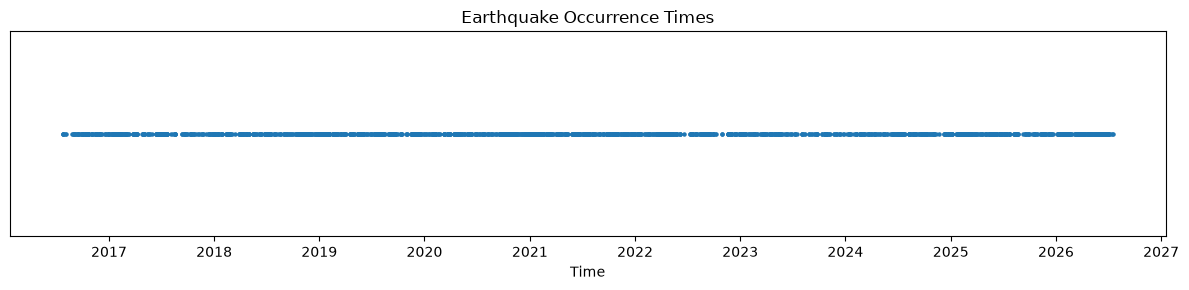

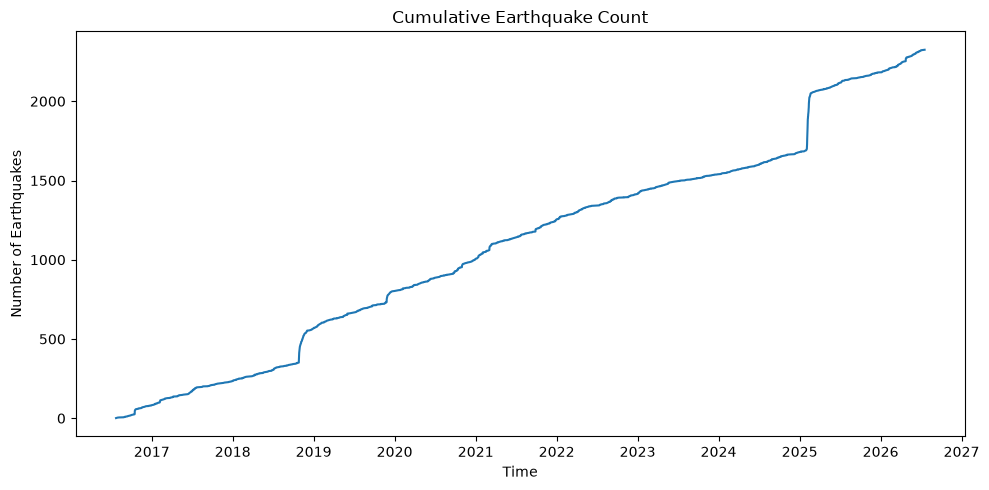

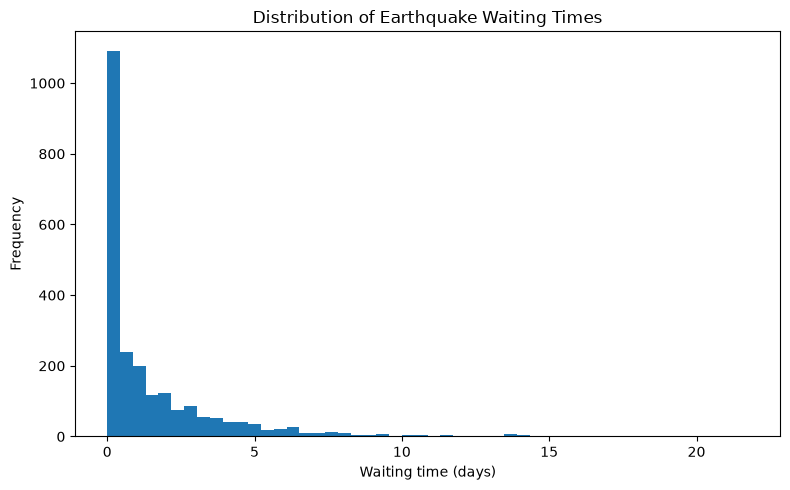


Waiting time statistics (days):
count    2324.000000
mean        1.569107
std         2.508987
min         0.000159
25%         0.055989
50%         0.541418
75%         2.042750
max        21.745952
Name: time, dtype: float64


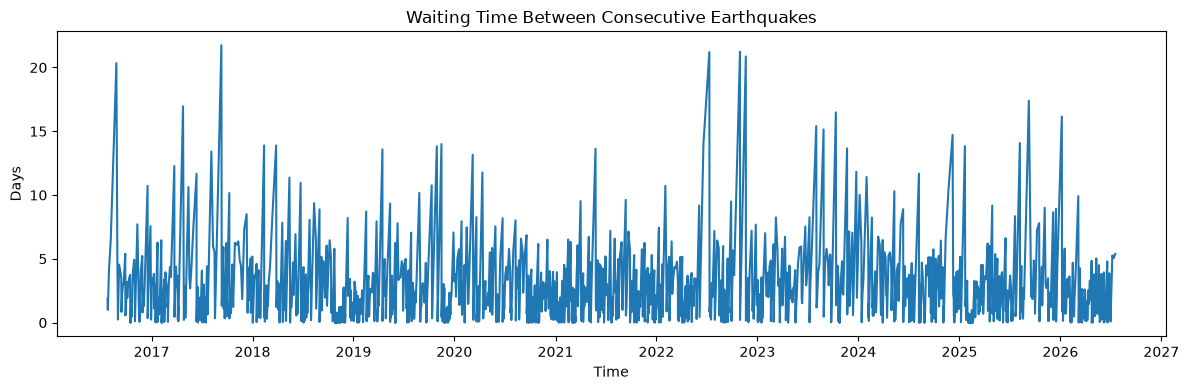

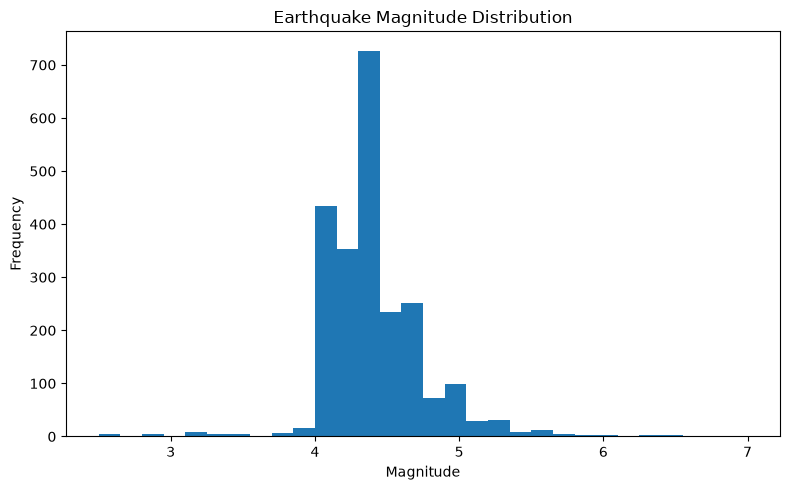


Conclusion:

The exploratory analysis shows whether earthquake events are
uniformly distributed in time or whether they occur in clusters.

If many short waiting times occur after periods of high activity,
a homogeneous Poisson process is unlikely to be sufficient.

This motivates the use of a Hawkes process, where each earthquake
temporarily increases the probability of future earthquakes.



In [1]:
# ==============================================================
# Notebook 1: Exploration of Earthquake Data
#
# Goal:
# - Load and clean earthquake data
# - Understand earthquake occurrence over time
# - Analyse inter-arrival times
# - Look for temporal clustering (motivation for Hawkes process)
#
# Dataset:
# data/earthquakes_greece_2016_2026.csv
# ==============================================================


# --------------------------------------------------------------
# 1. Imports
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# 2. Load data
# --------------------------------------------------------------

df = pd.read_csv("../data/earthquakes_greece_2016_2026.csv")

print(df.head())
print(df.info())


# --------------------------------------------------------------
# 3. Data cleaning
# --------------------------------------------------------------

# Convert time column to datetime
df["time"] = pd.to_datetime(df["time"])

# Sort chronologically
df = df.sort_values("time").reset_index(drop=True)

# Keep relevant columns
df = df[
    [
        "time",
        "latitude",
        "longitude",
        "depth",
        "mag",
        "place"
    ]
]

# Remove missing values
df = df.dropna()


# --------------------------------------------------------------
# 4. Basic statistics
# --------------------------------------------------------------

print("Number of earthquakes:", len(df))

print("\nMagnitude statistics:")
print(df["mag"].describe())

print("\nTime period:")
print(df["time"].min())
print(df["time"].max())


# --------------------------------------------------------------
# 5. Earthquake timeline
# --------------------------------------------------------------
# Each point represents one earthquake occurrence.

plt.figure(figsize=(12, 3))

plt.scatter(
    df["time"],
    np.ones(len(df)),
    s=5
)

plt.title("Earthquake Occurrence Times")
plt.xlabel("Time")

plt.yticks([])

plt.tight_layout()
plt.savefig("../figures/01_earthquake_timeline.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 6. Cumulative number of earthquakes
# --------------------------------------------------------------
# A constant-rate Poisson process would give an approximately
# linear curve.

plt.figure(figsize=(10, 5))

plt.plot(
    df["time"],
    np.arange(1, len(df) + 1)
)

plt.title("Cumulative Earthquake Count")
plt.xlabel("Time")
plt.ylabel("Number of Earthquakes")

plt.tight_layout()
plt.savefig("../figures/01_cumulative_count.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 7. Inter-arrival times
# --------------------------------------------------------------
# Time between consecutive earthquakes.

dt = df["time"].diff().dropna()

# Convert seconds to days
dt_days = dt.dt.total_seconds() / (24 * 3600)


# --------------------------------------------------------------
# 8. Waiting time distribution
# --------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    dt_days,
    bins=50
)

plt.title("Distribution of Earthquake Waiting Times")
plt.xlabel("Waiting time (days)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../figures/01_waiting_time_hist.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 9. Waiting time statistics
# --------------------------------------------------------------

print("\nWaiting time statistics (days):")
print(dt_days.describe())


# --------------------------------------------------------------
# 10. Waiting times through time
# --------------------------------------------------------------
# Clusters appear as many small waiting times close together.

plt.figure(figsize=(12, 4))

plt.plot(
    df["time"].iloc[1:],
    dt_days
)

plt.title("Waiting Time Between Consecutive Earthquakes")
plt.xlabel("Time")
plt.ylabel("Days")

plt.tight_layout()
plt.savefig("../figures/01_waiting_time_series.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 11. Magnitude distribution
# --------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["mag"],
    bins=30
)

plt.title("Earthquake Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../figures/01_magnitude_hist.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# Conclusion
# --------------------------------------------------------------

print("""
Conclusion:

The exploratory analysis shows whether earthquake events are
uniformly distributed in time or whether they occur in clusters.

If many short waiting times occur after periods of high activity,
a homogeneous Poisson process is unlikely to be sufficient.

This motivates the use of a Hawkes process, where each earthquake
temporarily increases the probability of future earthquakes.
""")